In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Advertising.csv")
df.drop('Index', axis=1, inplace=True)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
features_to_scale = ['TV', 'radio', 'newspaper']
scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.head()

,TV,radio,newspaper,sales
0,0.969852,0.981522,1.778945,22.1
1,-1.197376,1.082808,0.669579,10.4
2,-1.516155,1.528463,1.783549,9.3
3,0.052050,1.217855,1.286405,18.5
4,0.394182,-0.841614,1.281802,12.9


In [4]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], random_state=13)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(150, 3)
(50, 3)
(150,)
(50,)


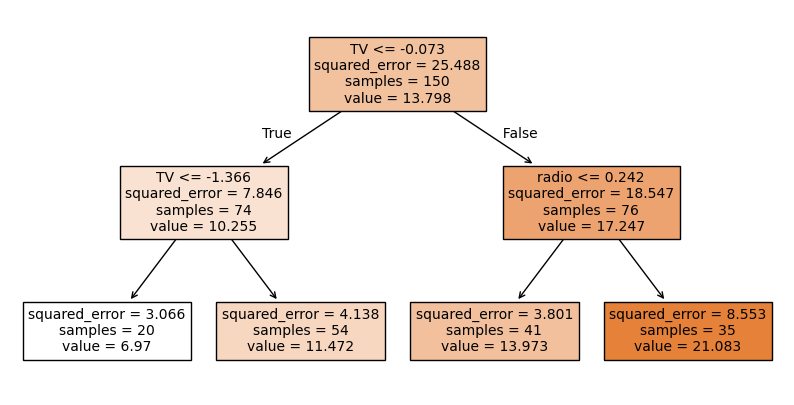

In [5]:
reg = DecisionTreeRegressor(max_depth=2, random_state=13)
reg = reg.fit(X_train, y_train)

plt.figure(figsize=(10,5))
plot_tree(reg,
          feature_names = df.columns, 
          class_names = ['positive', 'negative'], 
          filled = True, 
          fontsize = 10)
plt.show()

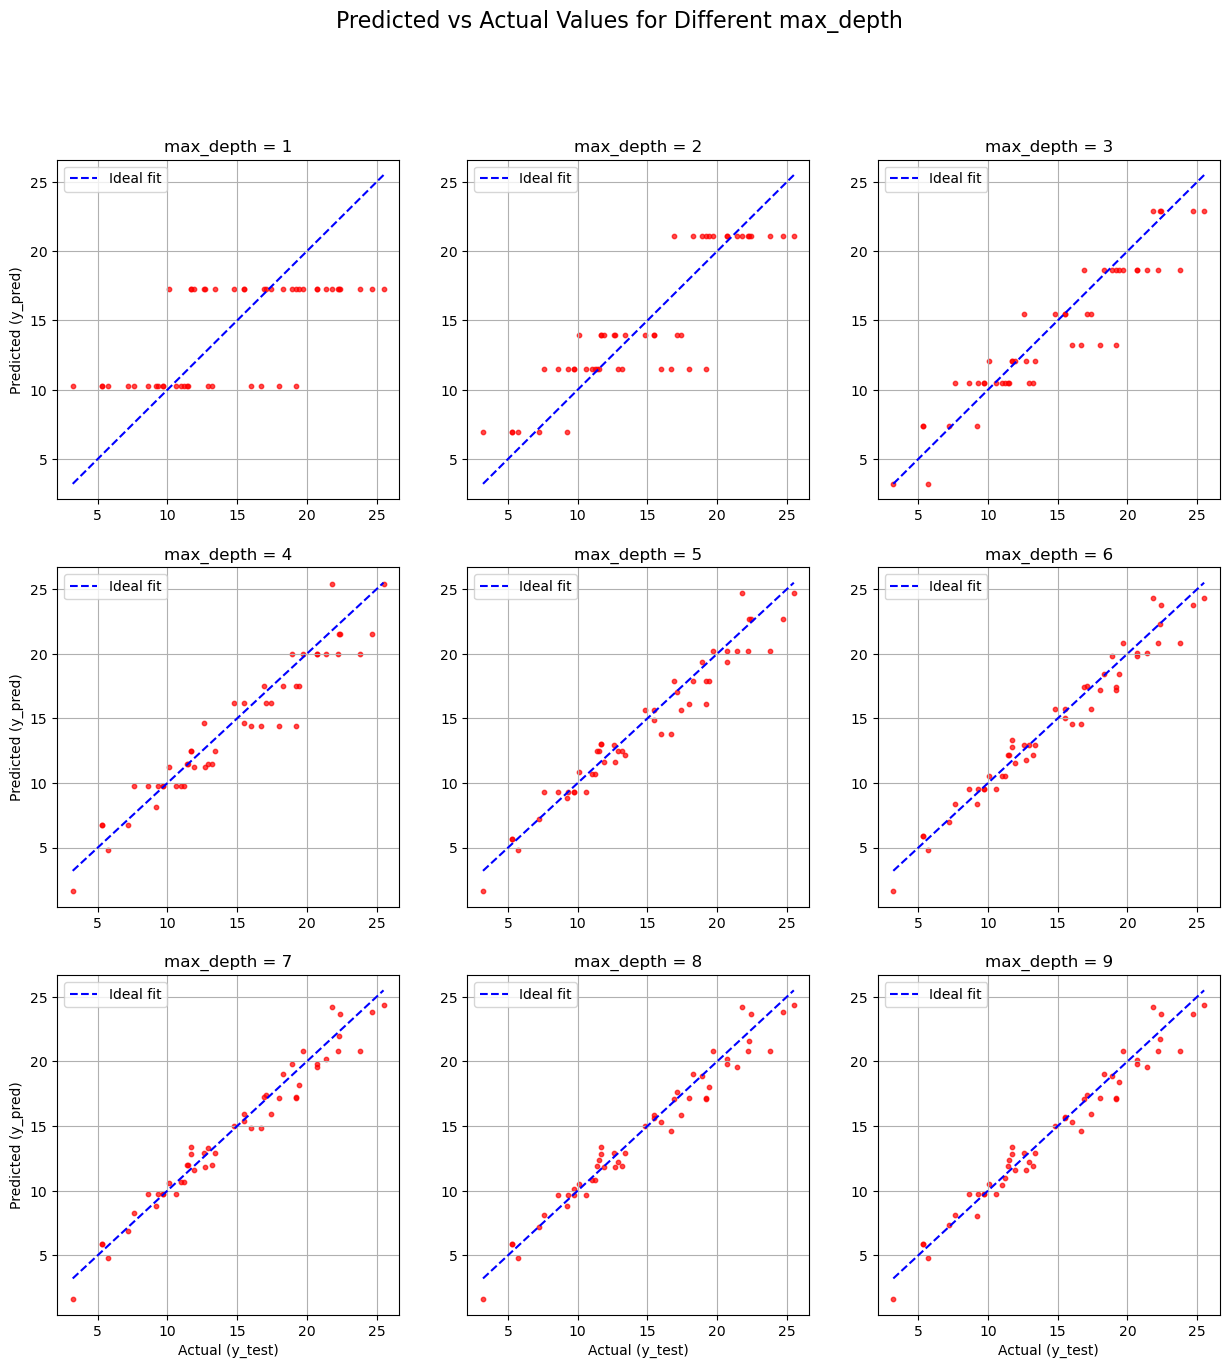

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
depth_values = [1, 2, 3,
                4, 5, 6,
                7, 8, 9]

for i, maxdepth in enumerate(depth_values):
    reg = DecisionTreeRegressor(max_depth=maxdepth, random_state=13)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.7, s=10, color='red')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            color='blue', linestyle='--', label='Ideal fit')
    ax.set_title(f"max_depth = {maxdepth}")
    
    if i % 3 == 0:  # First column of each row
        ax.set_ylabel("Predicted (y_pred)")
    if (i == 6 or i == 7 or i == 8):
        ax.set_xlabel("Actual (y_test)")
        
    ax.grid(True)
    ax.legend()
fig.suptitle("Predicted vs Actual Values for Different max_depth", fontsize=16)
plt.show()